<a href="https://colab.research.google.com/github/techn-0/computer_vision_STD/blob/main/8_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import tensorflow as tf
import tensorflow.keras.datasets as ds

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dropout, Dense
from tensorflow.keras.optimizers import SGD  # SGD로 변경

# 데이터 준비
(x_train, y_train), (x_test, y_test) = ds.mnist.load_data()
x_train = x_train.reshape(60000, 28, 28, 1)
x_test = x_test.reshape(10000, 28, 28, 1)
x_train = x_train.astype(np.float32) / 255.0
x_test = x_test.astype(np.float32) / 255.0
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

# 모델 선택
cnn = Sequential()

# 활성함수 tanh로 변경
cnn.add(Conv2D(6, (5, 5), padding='same', activation='tanh', input_shape=(28, 28, 1)))
cnn.add(MaxPooling2D(pool_size=(2, 2), strides=2))
cnn.add(Conv2D(16, (5, 5), padding='valid', activation='tanh'))
cnn.add(MaxPooling2D(pool_size=(2, 2), strides=2))
cnn.add(Conv2D(120, (5, 5), padding='valid', activation='tanh'))
cnn.add(Flatten())

# 은닉층 100으로
cnn.add(Dense(units=100, activation='tanh'))
cnn.add(Dense(units=10, activation='softmax'))

# 학습
# 옵티마이저 SGD(경사하강법) 변경, learning_rate 0.01
cnn.compile(loss='categorical_crossentropy',
            optimizer=SGD(learning_rate=0.01),
            metrics=['accuracy'])

# epochs 20으로 수정
cnn.fit(x_train, y_train,
        batch_size=128,
        epochs=20,
        validation_data=(x_test, y_test),
        verbose=2)

# 성능 측정
res = cnn.evaluate(x_test, y_test, verbose=0)
print('정확률 =', res[1] * 100)


Epoch 1/20
469/469 - 32s - 68ms/step - accuracy: 0.6880 - loss: 1.3278 - val_accuracy: 0.8817 - val_loss: 0.5375
Epoch 2/20
469/469 - 31s - 66ms/step - accuracy: 0.9012 - loss: 0.4037 - val_accuracy: 0.9244 - val_loss: 0.2971
Epoch 3/20
469/469 - 41s - 88ms/step - accuracy: 0.9291 - loss: 0.2706 - val_accuracy: 0.9393 - val_loss: 0.2224
Epoch 4/20
469/469 - 31s - 66ms/step - accuracy: 0.9415 - loss: 0.2137 - val_accuracy: 0.9479 - val_loss: 0.1824
Epoch 5/20
469/469 - 43s - 93ms/step - accuracy: 0.9499 - loss: 0.1799 - val_accuracy: 0.9554 - val_loss: 0.1548
Epoch 6/20
469/469 - 40s - 84ms/step - accuracy: 0.9560 - loss: 0.1565 - val_accuracy: 0.9617 - val_loss: 0.1358
Epoch 7/20
469/469 - 39s - 83ms/step - accuracy: 0.9615 - loss: 0.1394 - val_accuracy: 0.9648 - val_loss: 0.1204
Epoch 8/20
469/469 - 41s - 87ms/step - accuracy: 0.9651 - loss: 0.1259 - val_accuracy: 0.9674 - val_loss: 0.1091
Epoch 9/20
469/469 - 43s - 92ms/step - accuracy: 0.9677 - loss: 0.1150 - val_accuracy: 0.9709 - 

Epoch 1/10
391/391 - 155s - 398ms/step - accuracy: 0.3980 - loss: 1.6801 - val_accuracy: 0.5223 - val_loss: 1.3637
Epoch 2/10
391/391 - 199s - 509ms/step - accuracy: 0.5357 - loss: 1.3297 - val_accuracy: 0.5926 - val_loss: 1.1670
Epoch 3/10
391/391 - 205s - 525ms/step - accuracy: 0.5836 - loss: 1.1950 - val_accuracy: 0.5839 - val_loss: 1.1839
Epoch 4/10
391/391 - 201s - 513ms/step - accuracy: 0.6071 - loss: 1.1281 - val_accuracy: 0.6351 - val_loss: 1.0488
Epoch 5/10
391/391 - 199s - 510ms/step - accuracy: 0.6233 - loss: 1.0801 - val_accuracy: 0.6483 - val_loss: 1.0087
Epoch 6/10
391/391 - 206s - 526ms/step - accuracy: 0.6401 - loss: 1.0289 - val_accuracy: 0.6691 - val_loss: 0.9653
Epoch 7/10
391/391 - 201s - 515ms/step - accuracy: 0.6560 - loss: 0.9913 - val_accuracy: 0.6838 - val_loss: 0.9240
Epoch 8/10
391/391 - 200s - 511ms/step - accuracy: 0.6688 - loss: 0.9499 - val_accuracy: 0.6821 - val_loss: 0.9108
Epoch 9/10
391/391 - 202s - 518ms/step - accuracy: 0.6844 - loss: 0.9056 - val_a

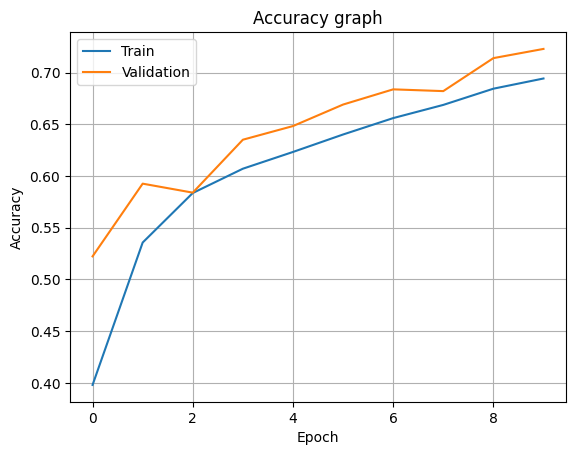

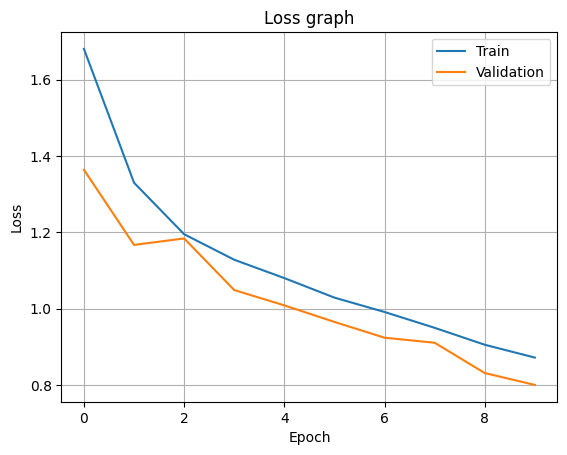

In [4]:
import numpy as np
import tensorflow as tf
import tensorflow.keras.datasets as ds

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import RMSprop  # 옵티마이저 변경 RMSprop

# 데이터 불러오기 및 전처리
(x_train, y_train), (x_test, y_test) = ds.cifar10.load_data()
x_train = x_train.astype(np.float32) / 255.0
x_test = x_test.astype(np.float32) / 255.0
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

# 모델 정의
cnn = Sequential()
# 활성함수 elu로 변경
cnn.add(Conv2D(32, (3, 3), activation='elu', input_shape=(32, 32, 3)))
cnn.add(Conv2D(32, (3, 3), activation='elu'))
cnn.add(MaxPooling2D(pool_size=(2, 2)))
cnn.add(Dropout(0.3))  # 드롭아웃 비율 0.3

cnn.add(Conv2D(64, (3, 3), activation='elu'))
cnn.add(Conv2D(64, (3, 3), activation='elu'))
cnn.add(MaxPooling2D(pool_size=(2, 2)))
cnn.add(Dropout(0.3))  # 드롭아웃 비율 0.3

cnn.add(Flatten())
cnn.add(Dense(units=256, activation='elu'))  # Dense 유닛 수 256
cnn.add(Dropout(0.4))  # 드롭아웃 비율 0.4
cnn.add(Dense(units=10, activation='softmax'))

#  옵티마이저 RMSprop, learning_rate=0.0005
cnn.compile(loss='categorical_crossentropy',
            optimizer=RMSprop(learning_rate=0.0005),
            metrics=['accuracy'])

# 학습 수행
hist = cnn.fit(x_train, y_train,
               batch_size=128,
               epochs=10,
               validation_data=(x_test, y_test),
               verbose=2)

# 평가 및 출력
res = cnn.evaluate(x_test, y_test, verbose=0)
print('정확률 =', res[1] * 100)

# 정확도 그래프
import matplotlib.pyplot as plt

plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('Accuracy graph')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.grid()
plt.show()

# 손실 그래프
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Loss graph')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.grid()
plt.show()


In [5]:
import numpy as np
import tensorflow as tf
import cv2 as cv
import matplotlib.pyplot as plt
import winsound

# 모델 버전 변경
model = tf.keras.models.load_model('cnn_v3_relu_dropout.h5')  # cnn_v3_relu_dropout.h5

def reset():
    global img
    img = np.ones((200, 520, 3), dtype=np.uint8) * 255
    for i in range(5):
        cv.rectangle(img, (10 + i * 100, 50), (10 + (i + 1) * 100, 150), (0, 0, 255))
    cv.putText(img, 'e:erase s:show r:recognition q:quit', (10, 40),
               cv.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 1)

def grab_numerals():
    numerals = []
    for i in range(5):
        roi = img[51:149, 11 + i * 100:9 + (i + 1) * 100, 0]
        roi = 255 - cv.resize(roi, (28, 28), interpolation=cv.INTER_CUBIC)
        numerals.append(roi)
    numerals = np.array(numerals)
    return numerals

def show():
    numerals = grab_numerals()
    plt.figure(figsize=(25, 5))
    for i in range(5):
        plt.subplot(1, 5, i + 1)
        plt.imshow(numerals[i], cmap='gray')
        plt.xticks([]); plt.yticks([])
    plt.show()

def recognition():
    numerals = grab_numerals()
    numerals = numerals.reshape(5, 28, 28, 1)
    numerals = numerals.astype(np.float32) / 255.0

    res = model.predict(numerals)
    top_val, top_idx = tf.math.top_k(res, k=1)  # class_id와 확률 추출

    for i in range(5):
        label = str(top_idx[i].numpy()[0])  # 예측 숫자
        confidence = top_val[i].numpy()[0] * 100  # 확신도(%)
        text = f"{label} ({confidence:.1f}%)"
        cv.putText(img, text, (30 + i * 100, 180), cv.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 1)

    winsound.Beep(1000, 500)

BrushSiz = 4
LColor = (0, 0, 0)

def writing(event, x, y, flags, param):
    if event == cv.EVENT_LBUTTONDOWN:
        cv.circle(img, (x, y), BrushSiz, LColor, -1)
    elif event == cv.EVENT_MOUSEMOVE and flags == cv.EVENT_FLAG_LBUTTON:
        cv.circle(img, (x, y), BrushSiz, LColor, -1)

reset()
cv.namedWindow('Writing')
cv.setMouseCallback('Writing', writing)

while True:
    cv.imshow('Writing', img)
    key = cv.waitKey(1)
    if key == ord('e'):
        reset()
    elif key == ord('s'):
        show()
    elif key == ord('r'):
        recognition()
    elif key == ord('q'):
        break

cv.destroyAllWindows()


ModuleNotFoundError: No module named 'winsound'

<ipython-input-7-228b6503f5d3>:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(class_names[int(y_train[i])])


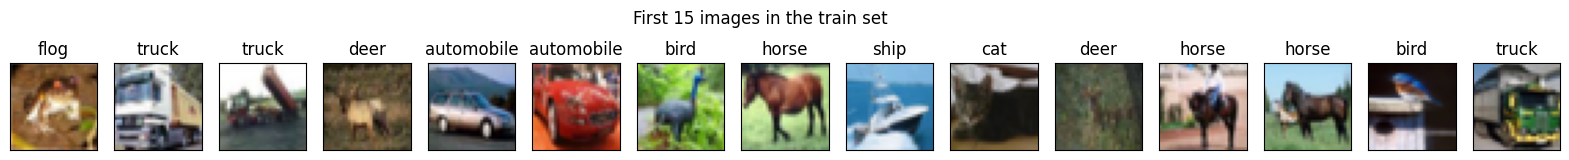

AttributeError: 'NumpyArrayIterator' object has no attribute 'next'

In [7]:
import tensorflow.keras.datasets as ds
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# 데이터셋 불러오기 및 전처리
(x_train, y_train), (x_test, y_test) = ds.cifar10.load_data()
x_train = x_train.astype('float32'); x_train /= 255
x_train = x_train[0:15, ]; y_train = y_train[0:15, ]  # 앞 15개 샘플만 증강 실험
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'flog', 'horse', 'ship', 'truck']

# 원본 이미지 시각화
plt.figure(figsize=(20, 2))
plt.suptitle("First 15 images in the train set")
for i in range(15):
    plt.subplot(1, 15, i + 1)
    plt.imshow(x_train[i])
    plt.xticks([]); plt.yticks([])
    plt.title(class_names[int(y_train[i])])
plt.show()

batch_siz = 4  # 한 번에 생성할 이미지 수 (미니 배치)

# 🔧 데이터 증강값 변경 (rotation, shift, flip)
generator = ImageDataGenerator(
    rotation_range=40.0,         # 회전 각도 40 으로
    width_shift_range=0.1,       # 이동 비율  0.1 으로
    height_shift_range=0.3,      # 수직 이동 비율 0.3 증가
    horizontal_flip=False        # 좌우 반전 제거 (True → False)
)

gen = generator.flow(x_train, y_train, batch_size=batch_siz)

# 증강된 이미지 3배치 확인
for a in range(3):
    img,label = gen.next()	# 미니 배치만큼 생성
    plt.figure(figsize=(8, 2.4))
    plt.suptitle("Generator trial " + str(a + 1))
    for i in range(batch_siz):
        plt.subplot(1, batch_siz, i + 1)
        plt.imshow(img[i])
        plt.xticks([]); plt.yticks([])
        plt.title(class_names[int(label[i])])
    plt.show()
